In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy.optimize import brentq

In [38]:


def schechter_function(L, L_star, alpha, phi_star=1.0):
    """
    Schechter luminosity function.
    
    φ(L) = φ* (L/L*)^α * exp(-L/L*)
    
    Parameters:
    -----------
    L : float or array
        Luminosity
    L_star : float
        Characteristic luminosity (knee of the function)
    alpha : float
        Faint-end slope (typically negative)
    phi_star : float
        Normalization constant (default: 1.0)
    
    Returns:
    --------
    phi : float or array
        Number density at luminosity L
    """
    x = L / L_star
    return phi_star * x**alpha * np.exp(-x)


def generate_schechter_luminosity(L_star, alpha, L_min=1e10, L_max=1e16):
    """
    Generate a single luminosity following the Schechter function.
    
    Uses rejection sampling method.
    
    Parameters:
    -----------
    L_star : float
        Characteristic luminosity in Jy·kpc²
    alpha : float
        Faint-end slope (typically -1.5 to -0.5 for FRBs)
    L_min : float
        Minimum luminosity (default: 1e10)
    L_max : float
        Maximum luminosity (default: 1e16)
    
    Returns:
    --------
    L : float
        Random luminosity following Schechter function
    """
    # Find maximum of Schechter function in the range for rejection sampling
    # Maximum occurs at L = alpha * L_star (for alpha > -1)
    if alpha > -1:
        L_max_func = max(alpha * L_star, L_min)
    else:
        L_max_func = L_min
    
    L_max_func = min(L_max_func, L_max)
    
    # Calculate envelope for rejection sampling
    phi_max = schechter_function(L_max_func, L_star, alpha)
    
    # Rejection sampling
    max_iterations = 1000
    for _ in range(max_iterations):
        # Sample uniformly in log space (more efficient for wide ranges)
        log_L = np.random.uniform(np.log10(L_min), np.log10(L_max))
        L = 10**log_L
        
        # Calculate acceptance probability
        phi_L = schechter_function(L, L_star, alpha)
        accept_prob = phi_L / phi_max
        
        if np.random.uniform(0, 1) < accept_prob:
            return L
    
    # If rejection sampling fails, fall back to approximate method
    print("Warning: Rejection sampling failed, using approximate method")
    return L_star * np.random.gamma(alpha + 1, 1)


def generate_schechter_luminosity_inverse_cdf(L_star, alpha, L_min=1e10, L_max=1e16, n_points=10000):
    """
    Generate luminosity using inverse CDF method (more accurate but slower).
    
    Parameters:
    -----------
    L_star : float
        Characteristic luminosity
    alpha : float
        Faint-end slope
    L_min : float
        Minimum luminosity
    L_max : float
        Maximum luminosity
    n_points : int
        Number of points for CDF interpolation
    
    Returns:
    --------
    L : float
        Random luminosity following Schechter function
    """
    # Build CDF by numerical integration
    L_grid = np.logspace(np.log10(L_min), np.log10(L_max), n_points)
    phi_vals = schechter_function(L_grid, L_star, alpha)
    
    # Cumulative integral using trapezoidal rule
    cdf = np.zeros_like(L_grid)
    for i in range(1, len(L_grid)):
        cdf[i] = cdf[i-1] + 0.5 * (phi_vals[i] + phi_vals[i-1]) * (L_grid[i] - L_grid[i-1])
    
    # Normalize CDF
    cdf = cdf / cdf[-1]
    
    # Draw random number and find corresponding luminosity
    u = np.random.uniform(0, 1)
    L = np.interp(u, cdf, L_grid)
    
    return L




In [39]:
# ============================================================================
# MAIN DEMONSTRATION
# ============================================================================

print("="*70)
print("GENERATING FRB LUMINOSITIES WITH SCHECHTER FUNCTION")
print("="*70)

# Schechter function parameters
L_star = 1e13  # Characteristic luminosity in Jy·kpc²
alpha = -0.8   # Faint-end slope (typical range: -1.5 to -0.5)
L_min = 1e10
L_max = 1e16
n_frbs = 1000000

print(f"\nSchechter Function: φ(L) = φ* (L/L*)^α * exp(-L/L*)")
print(f"\nParameters:")
print(f"  L* (characteristic luminosity): {L_star:.2e} Jy·kpc²")
print(f"  α (faint-end slope): {alpha}")
print(f"  Luminosity range: {L_min:.0e} - {L_max:.0e} Jy·kpc²")
print(f"  Number of FRBs: {n_frbs}")

# Generate FRB sample using rejection sampling
print("\nGenerating FRBs using rejection sampling...")
luminosities_rejection = []
for i in range(n_frbs):
    L = generate_schechter_luminosity(L_star, alpha, L_min, L_max)
    luminosities_rejection.append(L)
    if (i + 1) % 200 == 0:
        print(f"  Generated {i+1}/{n_frbs} FRBs...")

luminosities_rejection = np.array(sorted(luminosities_rejection))

print(f"\nStatistics (Rejection Sampling):")
print(f"  Min: {luminosities_rejection.min():.3e} Jy·kpc²")
print(f"  Median: {np.median(luminosities_rejection):.3e} Jy·kpc²")
print(f"  Mean: {np.mean(luminosities_rejection):.3e} Jy·kpc²")
print(f"  Max: {luminosities_rejection.max():.3e} Jy·kpc²")





GENERATING FRB LUMINOSITIES WITH SCHECHTER FUNCTION

Schechter Function: φ(L) = φ* (L/L*)^α * exp(-L/L*)

Parameters:
  L* (characteristic luminosity): 1.00e+13 Jy·kpc²
  α (faint-end slope): -0.8
  Luminosity range: 1e+10 - 1e+16 Jy·kpc²
  Number of FRBs: 1000000

Generating FRBs using rejection sampling...
  Generated 200/1000000 FRBs...
  Generated 400/1000000 FRBs...
  Generated 600/1000000 FRBs...
  Generated 800/1000000 FRBs...
  Generated 1000/1000000 FRBs...
  Generated 1200/1000000 FRBs...
  Generated 1400/1000000 FRBs...
  Generated 1600/1000000 FRBs...
  Generated 1800/1000000 FRBs...
  Generated 2000/1000000 FRBs...
  Generated 2200/1000000 FRBs...
  Generated 2400/1000000 FRBs...
  Generated 2600/1000000 FRBs...
  Generated 2800/1000000 FRBs...
  Generated 3000/1000000 FRBs...
  Generated 3200/1000000 FRBs...
  Generated 3400/1000000 FRBs...
  Generated 3600/1000000 FRBs...
  Generated 3800/1000000 FRBs...
  Generated 4000/1000000 FRBs...
  Generated 4200/1000000 FRBs...
 

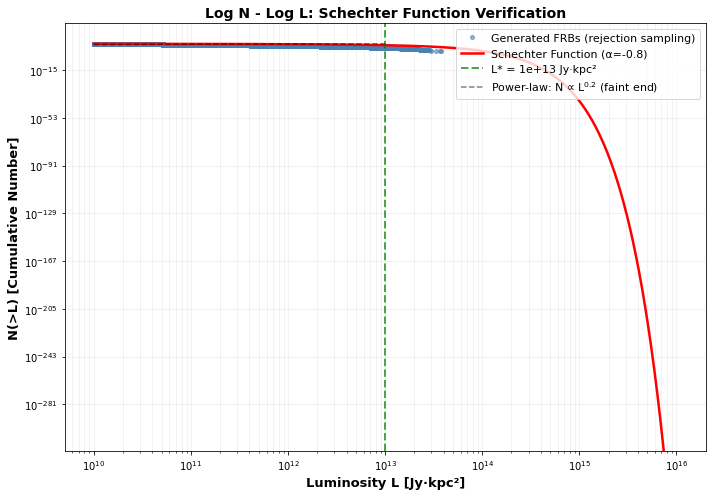


LOG N - LOG L PLOT GENERATED

Key features to verify:
  • Faint end (L << L*): Should follow power-law N ∝ L^0.2
  • Bright end (L >> L*): Should show exponential cutoff
  • Turnover near L* = 1e+13 Jy·kpc²


In [40]:
# ============================================================================
# LOG N - LOG L PLOT (Cumulative Distribution)
# ============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Sort luminosities in descending order for cumulative plot
L_sorted = np.sort(luminosities_rejection)[::-1]
N_cumulative = np.arange(1, len(L_sorted) + 1)

# Plot generated data
ax.loglog(L_sorted, N_cumulative, 'o', markersize=4, alpha=0.6, 
          color='steelblue', label='Generated FRBs (rejection sampling)')

# Theoretical Schechter cumulative distribution
L_theory = np.logspace(np.log10(L_min), np.log10(L_max), 10000)
phi_theory = schechter_function(L_theory, L_star, alpha)

# Integrate from L to L_max to get N(>L)
N_theory = np.zeros_like(L_theory)
for i in range(len(L_theory)):
    # Numerical integration from L_theory[i] to L_max
    L_integrate = L_theory[i:]
    phi_integrate = schechter_function(L_integrate, L_star, alpha)
    N_theory[i] = np.trapz(phi_integrate, L_integrate)

# Normalize to match the number of FRBs
N_theory = N_theory * (n_frbs / N_theory[0])

# Plot theoretical curve
ax.loglog(L_theory, N_theory, 'r-', linewidth=2.5, 
          label=f'Schechter Function (α={alpha})')

# Mark L_star
ax.axvline(L_star, color='green', linestyle='--', linewidth=2, 
           alpha=0.7, label=f'L* = {L_star:.0e} Jy·kpc²')

# Add power-law reference lines for comparison
L_ref = np.logspace(np.log10(L_min), np.log10(L_star), 100)
N_powerlaw = n_frbs * (L_ref / L_star)**(alpha + 1)
ax.loglog(L_ref, N_powerlaw, 'k--', linewidth=1.5, alpha=0.5,
          label=f'Power-law: N ∝ L$^{{{alpha+1:.1f}}}$ (faint end)')

ax.set_xlabel('Luminosity L [Jy·kpc²]', fontsize=13, fontweight='bold')
ax.set_ylabel('N(>L) [Cumulative Number]', fontsize=13, fontweight='bold')
ax.set_title('Log N - Log L: Schechter Function Verification', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, which='both', alpha=0.3, linestyle='-', linewidth=0.5)


plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("LOG N - LOG L PLOT GENERATED")
print("="*70)
print("\nKey features to verify:")
print(f"  • Faint end (L << L*): Should follow power-law N ∝ L^{alpha+1:.1f}")
print(f"  • Bright end (L >> L*): Should show exponential cutoff")
print(f"  • Turnover near L* = {L_star:.0e} Jy·kpc²")